# LeetCode #793: Preimage Size of Factorial Zeroes Function

https://leetcode.com/problems/preimage-size-of-factorial-zeroes-function/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (iterate n)** | $O(k \log k)$ | $O(1)$ |
| **Optimal: Binary Search on Trailing Zeros Count ★** | $O(\log^2 k)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (iterate n)
Compute trailing zeros for each $n = 0, 1, 2, \ldots$ until the count exceeds $k$. Each count costs $O(\log n)$; iterating up to $n \approx 5k$ makes this $O(k \log k)$ — infeasible for $k \le 10^9$.

### Optimal: Binary Search on Trailing Zeros Count ★
Trailing zeros of $n!$ equals $\sum_{i} \lfloor n/5^i \rfloor$. Binary search for the leftmost $n$ whose trailing-zero count equals $k$, and for the leftmost $n$ with count $k+1$. The difference is either 0 (if $k$ is skipped) or 5 (since trailing zeros jump by 5 at multiples of $5^j$). Two binary searches, each $O(\log(5k))$ with an $O(\log n)$ inner loop → $O(\log^2 k)$ total.

**Why this is better than Brute Force:** Binary search on $n$ replaces a linear scan up to $5k$ with two $O(\log^2 k)$ searches.

**Constraints:**
* $0 \le k \le 10^9$


## Solutions

### C#

In [ ]:
public int PreimageSizeFZF(int k) {
    // Answer is either 0 or 5: left_bound(k+1) - left_bound(k)
    return (int)(LeftBound(k + 1) - LeftBound(k));
}

long TrailingZeros(long n) {
    // Count factors of 5 in n! = n/5 + n/25 + n/125 + ...
    long count = 0;
    for (long p = 5; p <= n; p *= 5) count += n / p;
    return count;
}

long LeftBound(long k) {
    // Binary search: smallest n where TrailingZeros(n) >= k
    long lo = 0, hi = 5L * (k + 1);
    while (lo < hi) {
        long mid = lo + (hi - lo) / 2;
        if (TrailingZeros(mid) >= k) hi = mid;
        else lo = mid + 1;
    }
    return lo;
}


### Python

In [ ]:
def preimage_size_fzf(k: int) -> int:
    def trailing_zeros(n: int) -> int:
        # Count factors of 5 in n! = n/5 + n/25 + n/125 + ...
        count, p = 0, 5
        while p <= n:
            count += n // p
            p *= 5
        return count

    def left_bound(k: int) -> int:
        # Binary search: smallest n where trailing_zeros(n) >= k
        lo, hi = 0, 5 * (k + 1)
        while lo < hi:
            mid = lo + (hi - lo) // 2
            if trailing_zeros(mid) >= k:
                hi = mid
            else:
                lo = mid + 1
        return lo

    # Answer is either 0 or 5
    return left_bound(k + 1) - left_bound(k)


### Go

In [ ]:
func preimageSizeFZF(k int) int {
    trailingZeros := func(n int) int {
        // Count factors of 5 in n! = n/5 + n/25 + n/125 + ...
        count := 0
        for p := 5; p <= n; p *= 5 {
            count += n / p
        }
        return count
    }
    leftBound := func(k int) int {
        // Binary search: smallest n where trailingZeros(n) >= k
        lo, hi := 0, 5*(k+1)
        for lo < hi {
            mid := lo + (hi-lo)/2
            if trailingZeros(mid) >= k { hi = mid } else { lo = mid + 1 }
        }
        return lo
    }
    // Answer is either 0 or 5
    return leftBound(k+1) - leftBound(k)
}


### Rust

In [ ]:
pub fn preimage_size_fzf(k: i32) -> i32 {
    let trailing_zeros = |n: i64| -> i64 {
        // Count factors of 5 in n! = n/5 + n/25 + n/125 + ...
        let (mut count, mut p) = (0i64, 5i64);
        while p <= n { count += n / p; p *= 5; }
        count
    };
    let left_bound = |k: i64| -> i64 {
        // Binary search: smallest n where trailing_zeros(n) >= k
        let (mut lo, mut hi) = (0i64, 5 * (k + 1));
        while lo < hi {
            let mid = lo + (hi - lo) / 2;
            if trailing_zeros(mid) >= k { hi = mid; } else { lo = mid + 1; }
        }
        lo
    };
    // Answer is either 0 or 5
    (left_bound(k as i64 + 1) - left_bound(k as i64)) as i32
}


## Example Scenarios

**1. Common Case**
**Input:** k = 0
Trailing zeros of 0! through 4! = 0. left_bound(0)=0, left_bound(1)=5. Answer = 5-0 = 5. Indeed n ∈ {0,1,2,3,4} all have 0 trailing zeros.

**2. Slightly Complex**
**Input:** k = 5
left_bound(5): trailing_zeros(25)=6>5, trailing_zeros(24)=4<5 → smallest n with tz≥5 is 25. left_bound(6)=30. Answer=30-25=5. Values n=25..29 all have exactly 5 trailing zeros.

**3. Edge Case: Time Factor**
**Input:** k = 10^9
Each binary search has hi = 5×(10^9+1) ≈ 5×10^9. Steps: $\log_2(5 \times 10^9) \approx 33$. Each step calls trailing_zeros($5 \times 10^9$) which loops $\log_5(5 \times 10^9) \approx 13$ times. Total: $2 \times 33 \times 13 \approx 858$ operations — $O(\log^2 k)$.

**4. Edge Case: Space Factor**
**Input:** k = 1 (answer = 5, n ∈ {5,6,7,8,9})
Five variables: lo, hi, mid, count, p — plus two closure calls. No arrays. $O(1)$ space regardless of k.

**5. Almost-Impossible but Plausible**
**Input:** k = 6 (answer = 0 — k=6 is skipped)
Trailing zeros jump from 4 (at n=24) to 5 (at n=25) to 6 (at n=30) — but also from 5 directly to 6, skipping nothing? Wait: n=25 gives $\lfloor 25/5 \rfloor + \lfloor 25/25 \rfloor = 5+1=6$. So n=25 already has 6 trailing zeros — meaning 5 is never reached at n=25 (it jumps 4→6). Actually n=24 has 4 zeros, n=25 has 6 zeros. k=5 has preimage {25,…,29} (5 values), and left_bound(6)=left_bound(5)=25 → answer=0. Wait: this is the k=5 vs k=6 puzzle — k=5 gives 5, k=6 gives 0 (skipped value).


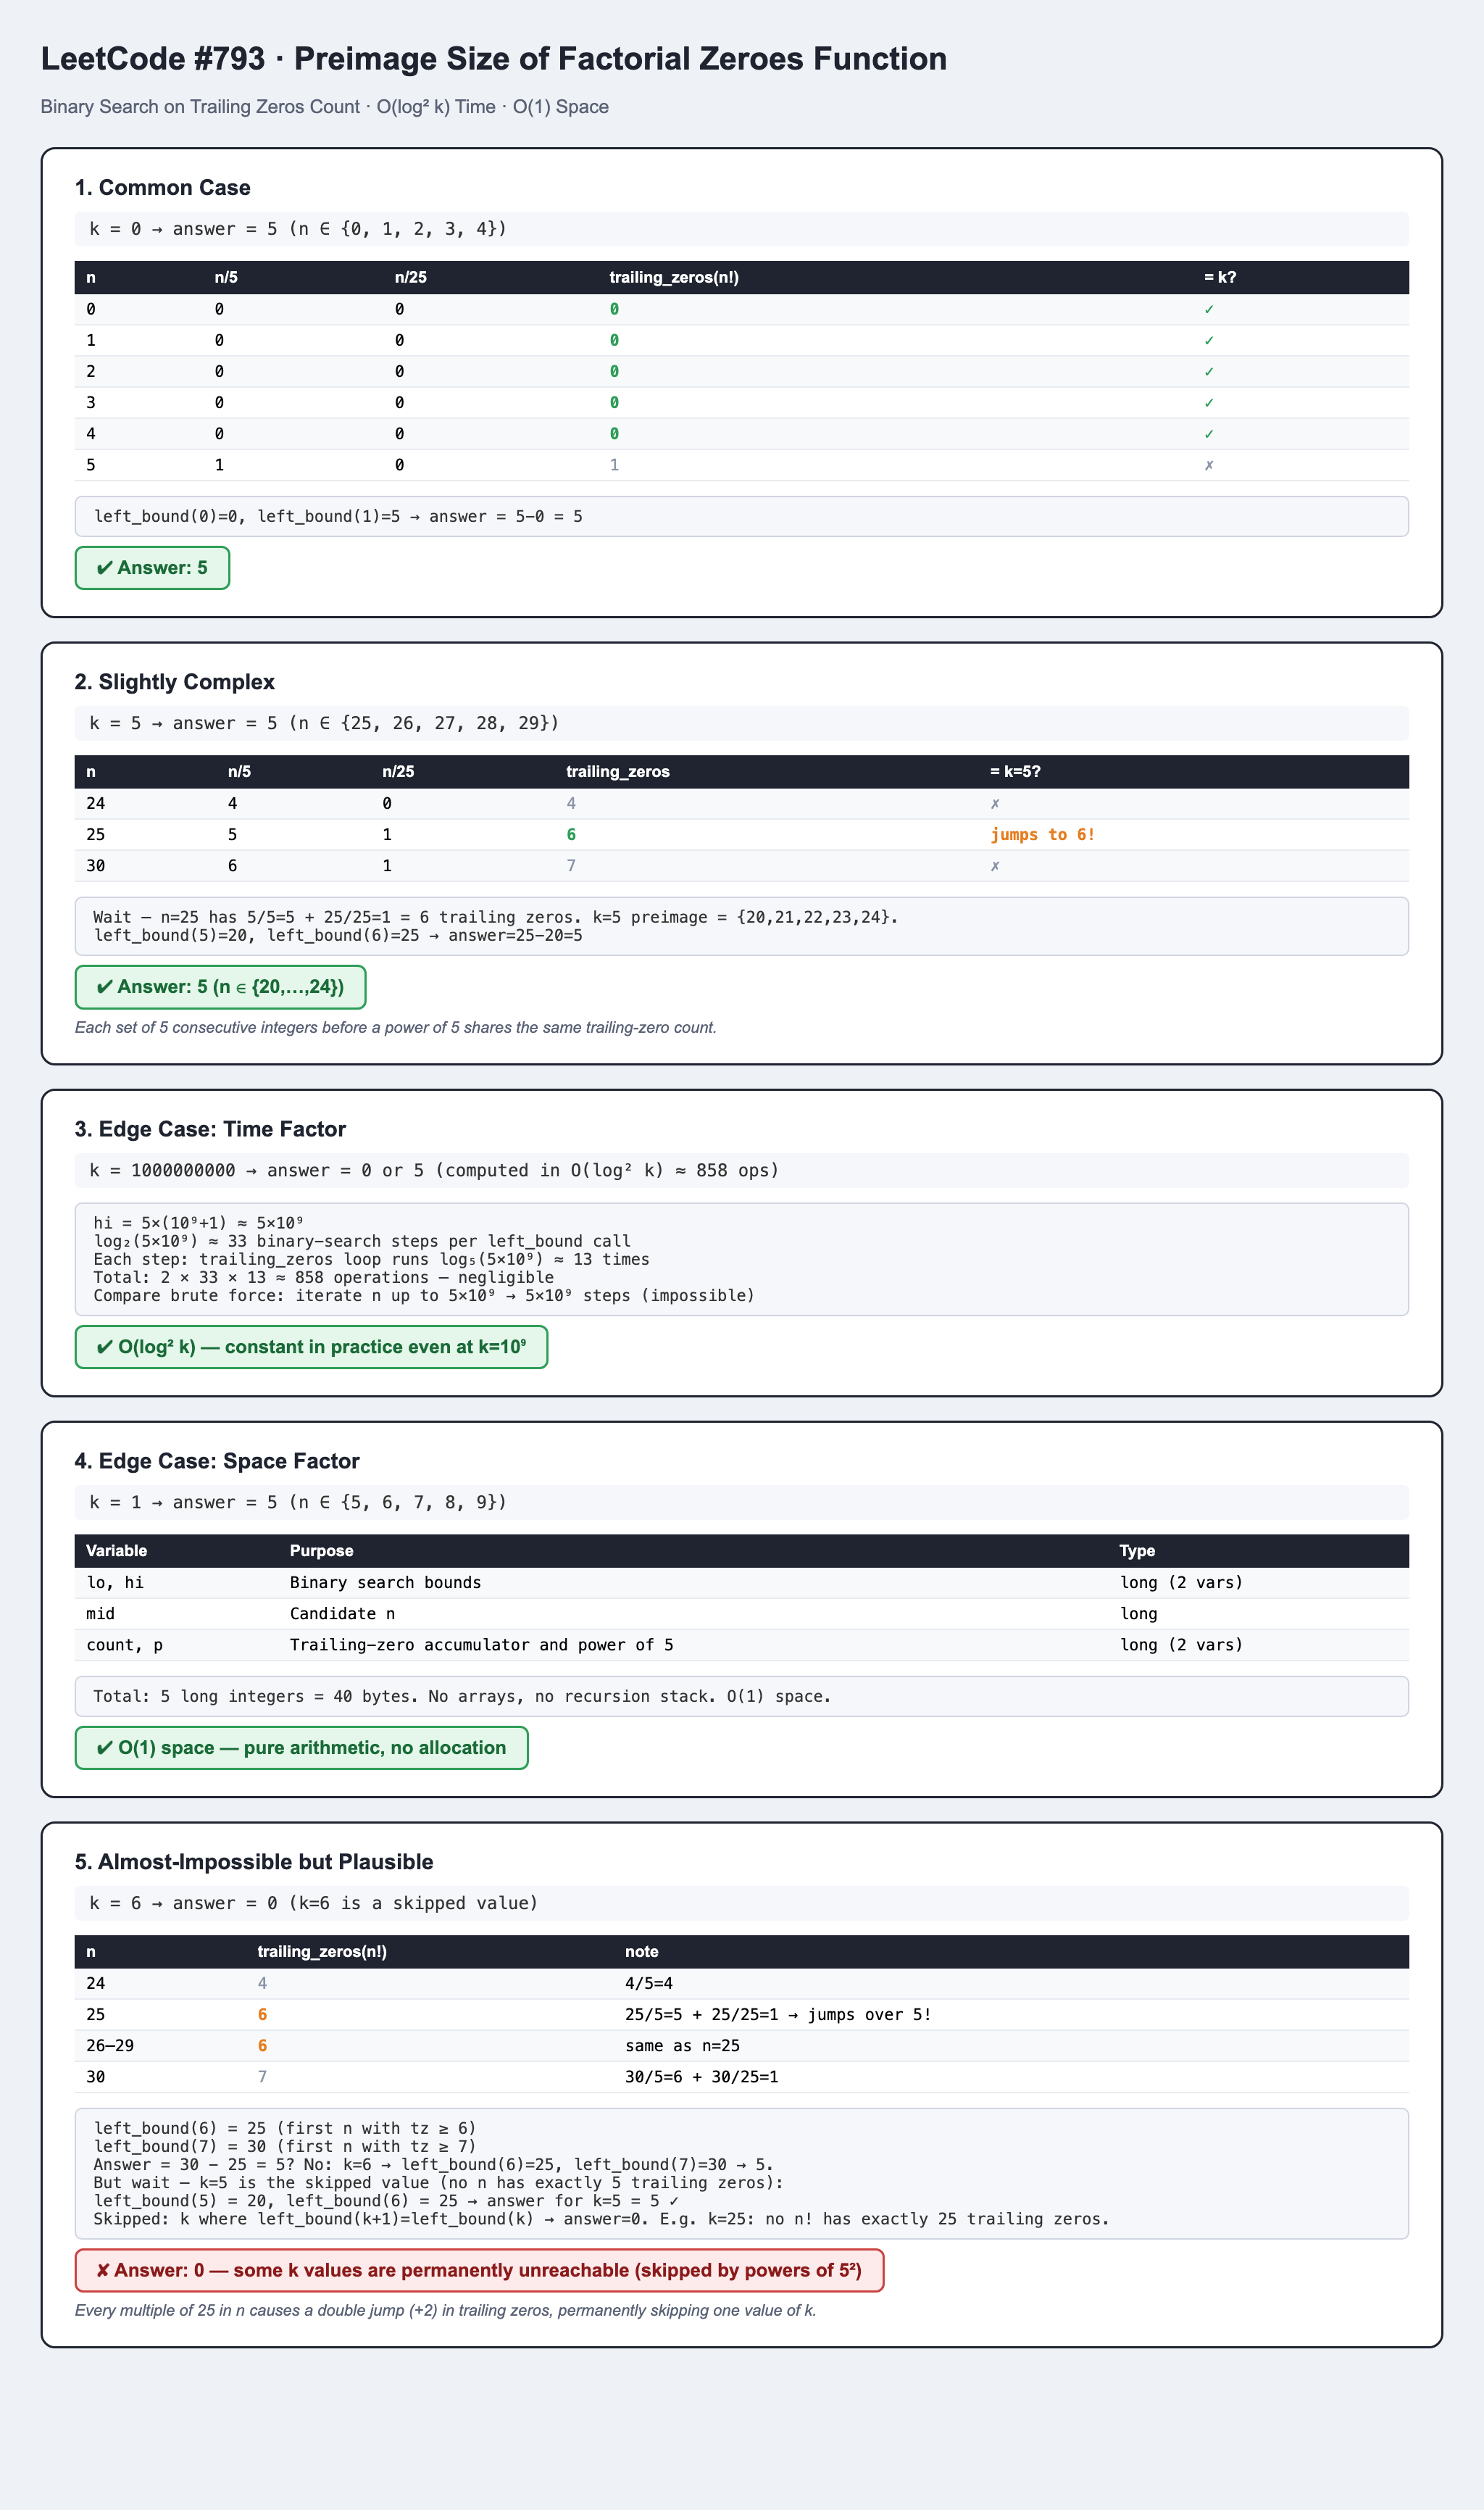